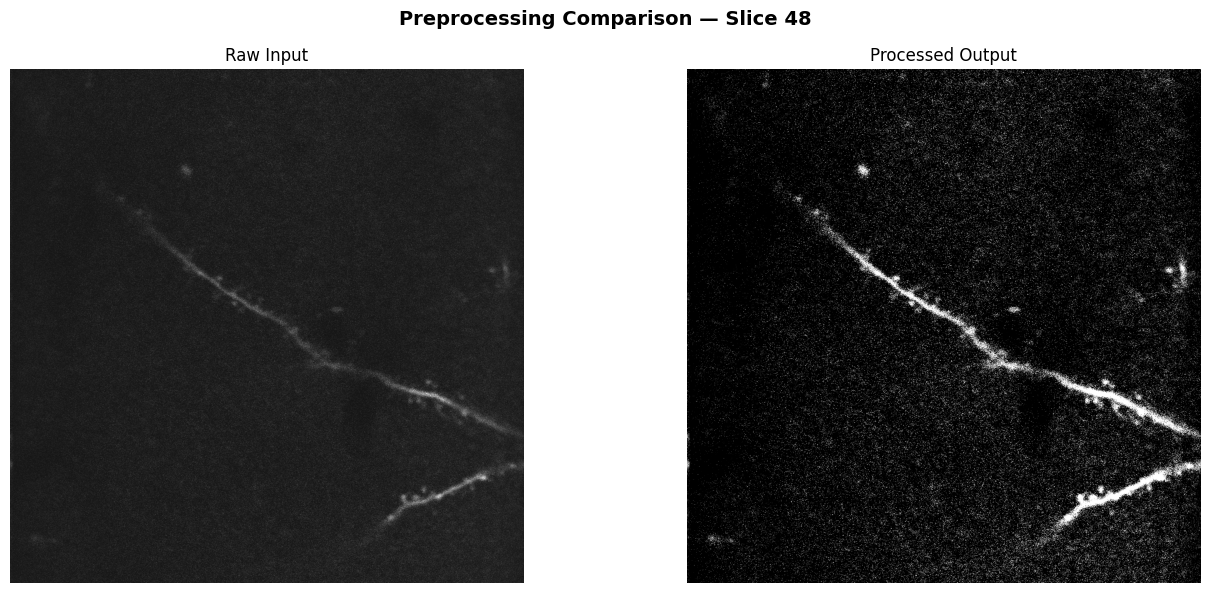

In [ ]:
'''
Preprocessing pipeline for 3D fluorescence .tif stacks for 2-photon
images. Applies global normalization, CLAHE, and percentile
contrast stretching before saving the result as a new .tif.

Inputs
- 3D .tif stack (Z, Y, X)

Outputs
- Processed .tif stack
'''

import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imsave
from skimage import exposure
from skimage.restoration import denoise_wavelet

# ------- CONFIGURATION -------
INPUT_PATH  = 'Inputs/processing/example_image.tif'
OUTPUT_DIR  = 'Output/image_processing'
OUTPUT_NAME = 'processed_example.tif'

# Global Normalization
NORM_LOW_PCT  = 0.5    # percentile for floor
NORM_HIGH_PCT = 99.5   # percentile for ceiling

# CLAHE
CLAHE_CLIP    = 0.005  # lower = less noise amplification

# Percentile Contrast Stretching
STRETCH_LOW   = 78     # all pixels in the bottom STRETCH_LOW percentile made black
STRETCH_HIGH  = 99.9   # all pixels above STRETCH_HIGH percentile made white
# ------------------------------

# Gloabl Norm - sets vmin and vmax based on the thresholds set the scales the whole
# image so that all pixels are between 0 and 1, just to reduce any outliers
image = imread(INPUT_PATH)
vmin, vmax = np.percentile(image, NORM_LOW_PCT), np.percentile(image, NORM_HIGH_PCT)
image_norm = np.clip((image - vmin) / (vmax - vmin), 0, 1)
image_uint = (image_norm * 65535).astype(np.uint16) 

# Adaptive Histogram Norm (CLAHE) - Runs CLAHE based on the clip which equalizes the
# histogram of intensites in small local patches so dim regions get contrast
# boosted independently. clip_limit caps amplification to prevent noise blowup
image_clahe = exposure.equalize_adapthist(image_uint, clip_limit=CLAHE_CLIP)

# Percentile Contrast Stretch - Same steps as global norm but with much harsher
# thresholds to remove background noise and amplfiy spines and dendrites
low, high = np.percentile(image_clahe, STRETCH_LOW), np.percentile(image_clahe, STRETCH_HIGH)
final = np.clip((image_clahe - low) / (high - low), 0, 1)
final = (final * 4095).astype(np.uint16)

# Makes sure the output directory exists, if it doesn't it will make it then save the
# processed image there based on the output name set
os.makedirs(OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(OUTPUT_DIR, OUTPUT_NAME)
imsave(save_path, final)

# Plot the pre and post processed images side by side at a designated slice
slice = 48

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Preprocessing Comparison — Slice {slice}', fontsize=14, fontweight='bold')

axes[0].imshow(image[slice], cmap='gray')
axes[0].set_title('Raw Input', fontsize=12)
axes[0].axis('off')

axes[1].imshow(final[slice], cmap='gray')
axes[1].set_title('Processed Output', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()